In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/loan_risk_dataset.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Basic Stats ===')
df.describe()

=== Data Types ===
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

=== Basic Stats ===


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [4]:
print('=== Null Value Counts ===')
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print(null_df)

=== Null Value Counts ===
                            Null Count  Null %
person_age                           0    0.00
person_income                        0    0.00
person_home_ownership                0    0.00
person_emp_length                  895    2.75
loan_intent                          0    0.00
loan_grade                           0    0.00
loan_amnt                            0    0.00
loan_int_rate                     3116    9.56
loan_status                          0    0.00
loan_percent_income                  0    0.00
cb_person_default_on_file            0    0.00
cb_person_cred_hist_length           0    0.00


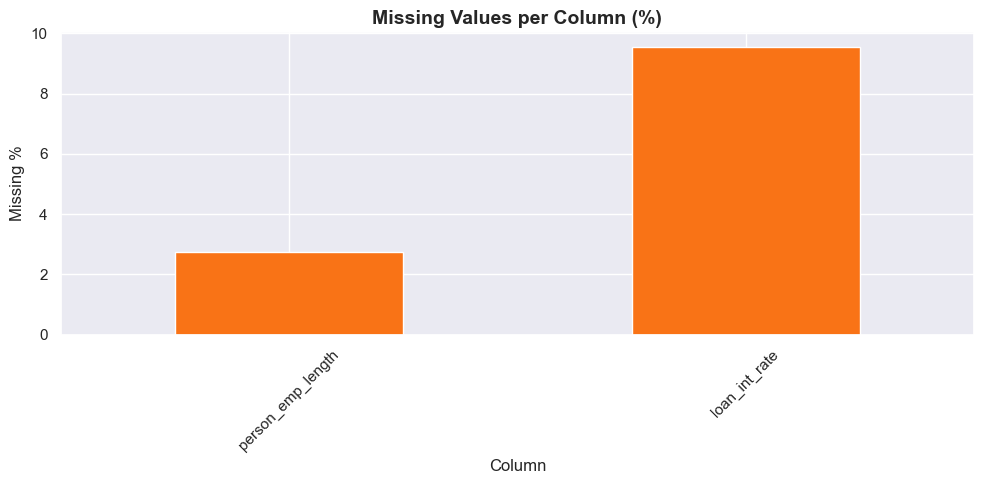

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
null_pct[null_pct > 0].plot(kind='bar', color='#f97316', ax=ax)
ax.set_title('Missing Values per Column (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

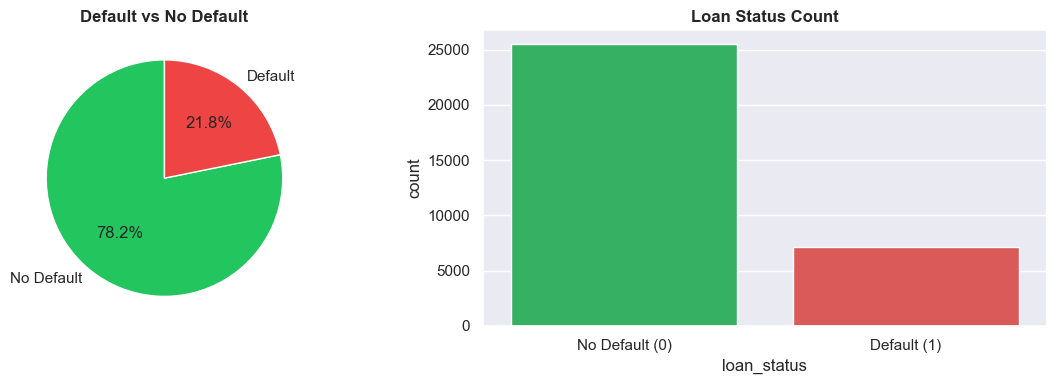

loan_status
0    25473
1     7108
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

loan_counts = df['loan_status'].value_counts()
axes[0].pie(loan_counts, labels=['No Default', 'Default'], autopct='%1.1f%%',
            colors=['#22c55e', '#ef4444'], startangle=90)
axes[0].set_title('Default vs No Default', fontweight='bold')

sns.countplot(data=df, x='loan_status', palette=['#22c55e', '#ef4444'], ax=axes[1])
axes[1].set_title('Loan Status Count', fontweight='bold')
axes[1].set_xticklabels(['No Default (0)', 'Default (1)'])

plt.tight_layout()
plt.show()
print(loan_counts)

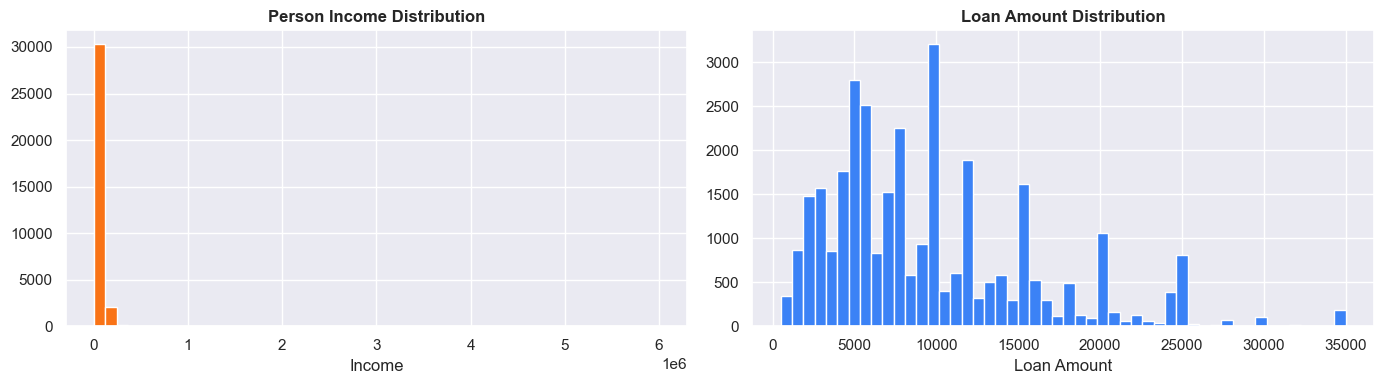

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['person_income'].hist(bins=50, color='#f97316', ax=axes[0])
axes[0].set_title('Person Income Distribution', fontweight='bold')
axes[0].set_xlabel('Income')

df['loan_amnt'].hist(bins=50, color='#3b82f6', ax=axes[1])
axes[1].set_title('Loan Amount Distribution', fontweight='bold')
axes[1].set_xlabel('Loan Amount')

plt.tight_layout()
plt.show()

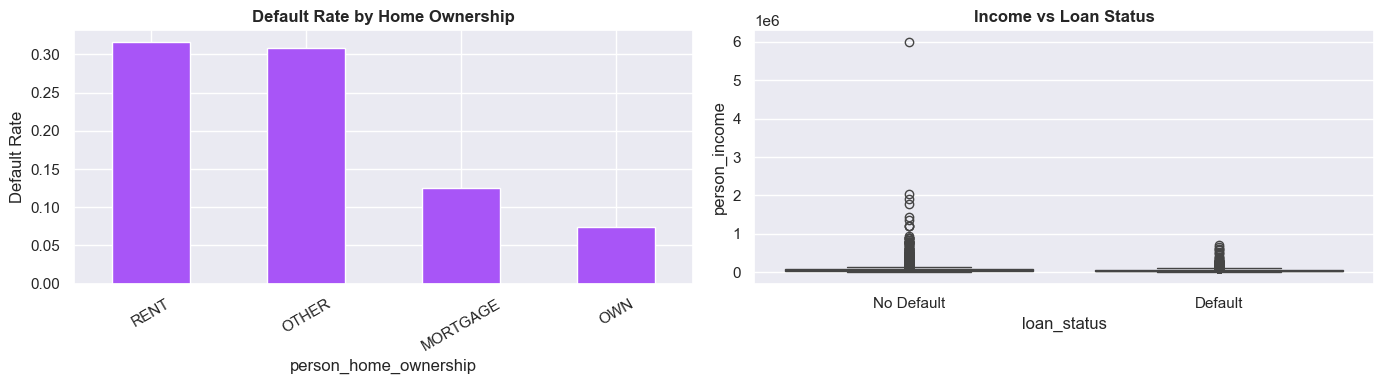

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

default_by_home = df.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False)
default_by_home.plot(kind='bar', color='#a855f7', ax=axes[0])
axes[0].set_title('Default Rate by Home Ownership', fontweight='bold')
axes[0].set_ylabel('Default Rate')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='loan_status', y='person_income',
            palette=['#22c55e', '#ef4444'], ax=axes[1])
axes[1].set_title('Income vs Loan Status', fontweight='bold')
axes[1].set_xticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()

In [9]:
print('Shape before cleaning:', df.shape)

# Drop rows where target is null
df = df.dropna(subset=['loan_status'])
print('Shape after dropping null target rows:', df.shape)

# Fill numeric nulls with median
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate']     = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print('Null values after cleaning:')
print(df.isnull().sum())

Shape before cleaning: (32581, 12)
Shape after dropping null target rows: (32581, 12)
Null values after cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [10]:
# Encode categorical columns
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'], drop_first=True)

print('Columns after encoding:', df.columns.tolist())
print('Shape:', df.shape)
df.head()

Columns after encoding: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']
Shape: (32581, 23)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True


In [11]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

print('Features shape:', X.shape)
print('Target distribution:', y.value_counts().to_dict())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling done')

Features shape: (32581, 22)
Target distribution: {0: 25473, 1: 7108}
Train: 26064 | Test: 6517
Scaling done


In [12]:
model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
model.fit(X_train_scaled, y_train)
print('Model trained successfully!')

Model trained successfully!


In [13]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
print('ROC-AUC Score:', round(roc_auc_score(y_test, y_proba), 4))

=== Classification Report ===
              precision    recall  f1-score   support

  No Default       0.93      0.99      0.96      5095
     Default       0.97      0.72      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517

ROC-AUC Score: 0.9423


In [14]:
# Lower threshold from 0.5 to 0.3 to catch more defaults
y_pred_adjusted = (y_proba >= 0.3).astype(int)

print('=== Adjusted Classification Report (threshold=0.3) ===')
print(classification_report(y_test, y_pred_adjusted, target_names=['No Default', 'Default']))

=== Adjusted Classification Report (threshold=0.3) ===
              precision    recall  f1-score   support

  No Default       0.93      0.97      0.95      5095
     Default       0.88      0.76      0.81      1422

    accuracy                           0.92      6517
   macro avg       0.91      0.86      0.88      6517
weighted avg       0.92      0.92      0.92      6517

